# SA Revised: Champion/Challenger vs Economists Consensus

This notebook pulls Reuters poll consensus from Unifier, aligns it to target month,
and compares it against:

- Champion: `_output/sandbox/sa_blend_walkforward/backtest_results.csv`
- Challenger: `_output/SA_prediction_revised/backtest_results.csv`

You will get:

1. Two 3-line charts (actual, model prediction, economists prediction)
2. Two metric tables (model vs economists) with RMSE, MAE, direction, acceleration, and variance diagnostics


In [18]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "settings.py").exists() and (candidate / "Train").exists():
            return candidate
    raise RuntimeError("Could not find repo root (expected settings.py and Train/)")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from Train.variance_metrics import compute_variance_kpis

CHAMPION_BACKTEST = REPO_ROOT / "_output/sandbox/sa_blend_walkforward/backtest_results.csv"
CHALLENGER_BACKTEST = REPO_ROOT / "_output/SA_prediction_revised/backtest_results.csv"

# You can change these for different economist keys.
UNIFIER_USER = os.getenv("UNIFIER_USER", "demo")
UNIFIER_TOKEN = os.getenv("UNIFIER_TOKEN", "qZy7KpE+L5Fg2MmjFqC/1xmweo7pgnnACCcK3JNEAec=")
POLL_NAME = "lseg_us_reuters_polls"
POLL_KEY = "US&NFAREO"

CONSENSUS_DATE_COL = "timestamp"
CONSENSUS_VALUE_COL = "latest_revised_actual_value"

# Optional: limit displayed comparison window.
DISPLAY_START = None  # example: "2023-03-01"

print("REPO_ROOT:", REPO_ROOT)
print("Champion backtest:", CHAMPION_BACKTEST)
print("Challenger backtest:", CHALLENGER_BACKTEST)


REPO_ROOT: /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor
Champion backtest: /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor/_output/sandbox/sa_blend_walkforward/backtest_results.csv
Challenger backtest: /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor/_output/SA_prediction_revised/backtest_results.csv


In [19]:
from unifier import unifier

unifier.user = UNIFIER_USER
unifier.token = UNIFIER_TOKEN
os.environ["UNIFIER_USER"] = UNIFIER_USER
os.environ["UNIFIER_TOKEN"] = UNIFIER_TOKEN

poll_df = unifier.get_dataframe(name=POLL_NAME, key=POLL_KEY, asof_date=None)
print(f"Pulled {len(poll_df):,} rows from {POLL_NAME} ({POLL_KEY})")
display(poll_df.head())


Pulled 315 rows from lseg_us_reuters_polls (US&NFAREO)


,date,asof_date,timestamp,ident,name,description,last_revision_date,latest_revised_actual_value,economic_series_magnitude,latest_revised_value,...,first_release_date,first_release_value,initial_value_on_business_date,last_known_value_on_business_date_minus_1,last_known_value_on_business_date_minus_2,vintage_data,frequency,adjustment,country,asof_muts
0,2026-02-26,2026-02-26 15:30:08.419,1999-04-15 00:00:00.000,US&NFAREO,NON-FARM PAYROLLS-MEAN,"United States, Employment, Non-Farm Payrolls-M...",1999-05-03 00:00:00.000,230,1000,0.230,...,1999-05-03 00:00:00.000,230,230.0,NaN,NaN,230,Monthly,"Volumes, seasonally adjusted",United States,1.772120e+09
1,2026-02-26,2026-02-26 15:30:08.419,1999-06-15 00:00:00.000,US&NFAREO,NON-FARM PAYROLLS-MEAN,"United States, Employment, Non-Farm Payrolls-M...",1999-06-28 00:00:00.000,220,1000,0.220,...,1999-06-28 00:00:00.000,220,220.0,NaN,230.0,220,Monthly,"Volumes, seasonally adjusted",United States,1.772120e+09
2,2026-02-26,2026-02-26 15:30:08.419,1999-07-15 00:00:00.000,US&NFAREO,NON-FARM PAYROLLS-MEAN,"United States, Employment, Non-Farm Payrolls-M...",1999-08-02 00:00:00.000,201,1000,0.201,...,1999-08-02 00:00:00.000,201,201.0,220.0,NaN,201,Monthly,"Volumes, seasonally adjusted",United States,1.772120e+09
3,2026-02-26,2026-02-26 15:30:08.419,1999-08-15 00:00:00.000,US&NFAREO,NON-FARM PAYROLLS-MEAN,"United States, Employment, Non-Farm Payrolls-M...",1999-08-30 00:00:00.000,211,1000,0.211,...,1999-08-30 00:00:00.000,211,211.0,201.0,220.0,211,Monthly,"Volumes, seasonally adjusted",United States,1.772120e+09
4,2026-02-26,2026-02-26 15:30:08.419,1999-10-15 00:00:00.000,US&NFAREO,NON-FARM PAYROLLS-MEAN,"United States, Employment, Non-Farm Payrolls-M...",1999-11-01 00:00:00.000,313,1000,0.313,...,1999-11-01 00:00:00.000,313,313.0,NaN,211.0,313,Monthly,"Volumes, seasonally adjusted",United States,1.772120e+09


In [20]:
def prepare_consensus_monthly(
    df: pd.DataFrame,
    date_col: str = CONSENSUS_DATE_COL,
    value_col: str = CONSENSUS_VALUE_COL,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    required = [date_col, value_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing required consensus columns: {missing}")

    x = df.copy()
    x[date_col] = pd.to_datetime(x[date_col], errors="coerce")
    x[value_col] = pd.to_numeric(x[value_col], errors="coerce")
    x = x.dropna(subset=[date_col, value_col]).copy()

    # Reuters timestamp uses the 15th; normalize to month start to match model ds.
    x["ds"] = x[date_col].dt.to_period("M").dt.to_timestamp()
    x = x.sort_values(date_col)

    monthly = (
        x.groupby("ds", as_index=False)
         .agg(
             consensus_pred=(value_col, "last"),
             consensus_mean=(value_col, "mean"),
             consensus_median=(value_col, "median"),
             consensus_std=(value_col, "std"),
             consensus_rows=(value_col, "size"),
         )
    )

    return monthly, x


consensus_monthly, consensus_clean = prepare_consensus_monthly(poll_df)
print("Consensus monthly rows:", len(consensus_monthly))
display(consensus_monthly.tail(12))


Consensus monthly rows: 315


,ds,consensus_pred,consensus_mean,consensus_median,consensus_std,consensus_rows
303,2025-03-01,133,133.0,133.0,NaN,1
304,2025-04-01,128,128.0,128.0,NaN,1
305,2025-05-01,135,135.0,135.0,NaN,1
306,2025-06-01,110,110.0,110.0,NaN,1
307,2025-07-01,108,108.0,108.0,NaN,1
308,2025-08-01,75,75.0,75.0,NaN,1
309,2025-09-01,52,52.0,52.0,NaN,1
310,2025-10-01,-9,-9.0,-9.0,NaN,1
311,2025-11-01,49,49.0,49.0,NaN,1
312,2025-12-01,65,65.0,65.0,NaN,1


In [21]:
def load_model_backtest(path: Path, pred_name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    needed = ["ds", "actual", "predicted"]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f"{path} missing columns: {missing}")

    out = df[["ds", "actual", "predicted"]].copy()
    out["ds"] = pd.to_datetime(out["ds"], errors="coerce").dt.to_period("M").dt.to_timestamp()
    out["actual"] = pd.to_numeric(out["actual"], errors="coerce")
    out["predicted"] = pd.to_numeric(out["predicted"], errors="coerce")

    out = out.dropna(subset=["ds"]).sort_values("ds")
    out = out.rename(
        columns={
            "actual": f"actual_{pred_name}",
            "predicted": pred_name,
        }
    )
    return out


champ_df = load_model_backtest(CHAMPION_BACKTEST, "champion_pred")
chall_df = load_model_backtest(CHALLENGER_BACKTEST, "challenger_pred")

comparison_df = (
    consensus_monthly[["ds", "consensus_pred", "consensus_mean", "consensus_median", "consensus_std", "consensus_rows"]]
    .merge(champ_df, on="ds", how="outer")
    .merge(chall_df, on="ds", how="outer")
    .sort_values("ds")
)

comparison_df["actual"] = comparison_df["actual_champion_pred"].combine_first(
    comparison_df["actual_challenger_pred"]
)

if DISPLAY_START is not None:
    comparison_df = comparison_df[comparison_df["ds"] >= pd.Timestamp(DISPLAY_START)].copy()

actual_overlap = comparison_df[["actual_champion_pred", "actual_challenger_pred"]].dropna()
if not actual_overlap.empty:
    mismatch = (actual_overlap["actual_champion_pred"] != actual_overlap["actual_challenger_pred"]).sum()
    print(f"Actual overlap rows: {len(actual_overlap)} | mismatches: {mismatch}")

print("Rows with all three values (champion + consensus + actual):", int(comparison_df[["actual", "champion_pred", "consensus_pred"]].dropna().shape[0]))
print("Rows with all three values (challenger + consensus + actual):", int(comparison_df[["actual", "challenger_pred", "consensus_pred"]].dropna().shape[0]))

display(comparison_df.tail(12))


Actual overlap rows: 35 | mismatches: 0
Rows with all three values (champion + consensus + actual): 35
Rows with all three values (challenger + consensus + actual): 35


,ds,consensus_pred,consensus_mean,consensus_median,consensus_std,consensus_rows,actual_champion_pred,champion_pred,actual_challenger_pred,challenger_pred,actual
303,2025-03-01,133,133.0,133.0,NaN,1,228.0,350.130348,228.0,197.936741,228.0
304,2025-04-01,128,128.0,128.0,NaN,1,177.0,-19.734965,177.0,144.154158,177.0
305,2025-05-01,135,135.0,135.0,NaN,1,139.0,265.509558,139.0,251.311458,139.0
306,2025-06-01,110,110.0,110.0,NaN,1,147.0,221.706043,147.0,160.439687,147.0
307,2025-07-01,108,108.0,108.0,NaN,1,73.0,162.353398,73.0,148.030337,73.0
308,2025-08-01,75,75.0,75.0,NaN,1,22.0,108.912794,22.0,109.225260,22.0
309,2025-09-01,52,52.0,52.0,NaN,1,119.0,120.215247,119.0,83.739104,119.0
310,2025-10-01,-9,-9.0,-9.0,NaN,1,-138.0,81.528732,-138.0,133.156464,-138.0
311,2025-11-01,49,49.0,49.0,NaN,1,64.0,105.888639,64.0,-71.243833,64.0
312,2025-12-01,65,65.0,65.0,NaN,1,50.0,106.538267,50.0,137.456130,50.0


In [22]:
def forecast_metrics(actual: pd.Series, pred: pd.Series) -> dict:
    z = pd.DataFrame({"actual": actual, "pred": pred}).dropna().copy()
    if z.empty:
        return {
            "N": 0,
            "RMSE": np.nan,
            "MAE": np.nan,
            "MSE": np.nan,
            "ME_Bias": np.nan,
            "MedAE": np.nan,
            "SMAPE_pct": np.nan,
            "Directional_Accuracy": np.nan,
            "Acceleration_Accuracy": np.nan,
            "STD_Ratio": np.nan,
            "Diff_STD_Ratio": np.nan,
            "Corr_Level": np.nan,
            "Corr_Diff": np.nan,
            "Diff_Sign_Accuracy": np.nan,
            "Tail_MAE": np.nan,
            "Extreme_Hit_Rate": np.nan,
        }

    a = z["actual"].to_numpy(dtype=float)
    p = z["pred"].to_numpy(dtype=float)
    e = a - p

    mse = float(np.mean(e ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(e)))
    me = float(np.mean(e))
    medae = float(np.median(np.abs(e)))
    smape = float(np.mean(2.0 * np.abs(e) / (np.abs(a) + np.abs(p) + 1e-12)) * 100.0)

    directional = float(np.mean(np.sign(a) == np.sign(p)))
    if len(a) >= 2:
        acceleration = float(np.mean(np.sign(np.diff(a)) == np.sign(np.diff(p))))
    else:
        acceleration = np.nan

    vk = compute_variance_kpis(a, p)

    return {
        "N": int(len(z)),
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "ME_Bias": me,
        "MedAE": medae,
        "SMAPE_pct": smape,
        "Directional_Accuracy": directional,
        "Acceleration_Accuracy": acceleration,
        "STD_Ratio": float(vk["std_ratio"]),
        "Diff_STD_Ratio": float(vk["diff_std_ratio"]),
        "Corr_Level": float(vk["corr_level"]),
        "Corr_Diff": float(vk["corr_diff"]),
        "Diff_Sign_Accuracy": float(vk["diff_sign_accuracy"]),
        "Tail_MAE": float(vk["tail_mae"]),
        "Extreme_Hit_Rate": float(vk["extreme_hit_rate"]),
    }


def build_model_vs_consensus_table(df: pd.DataFrame, model_col: str, model_label: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    common = df[["ds", "actual", model_col, "consensus_pred"]].dropna().copy()

    model_row = {"Forecast": model_label, **forecast_metrics(common["actual"], common[model_col])}
    econ_row = {"Forecast": "Economists_Consensus", **forecast_metrics(common["actual"], common["consensus_pred"])}

    table = pd.DataFrame([model_row, econ_row]).set_index("Forecast")
    metric_order = [
        "N",
        "RMSE",
        "MAE",
        "MSE",
        "ME_Bias",
        "MedAE",
        "SMAPE_pct",
        "Directional_Accuracy",
        "Acceleration_Accuracy",
        "STD_Ratio",
        "Diff_STD_Ratio",
        "Corr_Level",
        "Corr_Diff",
        "Diff_Sign_Accuracy",
        "Tail_MAE",
        "Extreme_Hit_Rate",
    ]
    table = table[metric_order]

    return common, table


champ_common, champ_table = build_model_vs_consensus_table(comparison_df, "champion_pred", "Champion_Blend")
chall_common, chall_table = build_model_vs_consensus_table(comparison_df, "challenger_pred", "Challenger_LightGBM")

fmt = {
    "N": "{:.0f}",
    "RMSE": "{:.3f}",
    "MAE": "{:.3f}",
    "MSE": "{:.3f}",
    "ME_Bias": "{:.3f}",
    "MedAE": "{:.3f}",
    "SMAPE_pct": "{:.2f}",
    "Directional_Accuracy": "{:.3f}",
    "Acceleration_Accuracy": "{:.3f}",
    "STD_Ratio": "{:.3f}",
    "Diff_STD_Ratio": "{:.3f}",
    "Corr_Level": "{:.3f}",
    "Corr_Diff": "{:.3f}",
    "Diff_Sign_Accuracy": "{:.3f}",
    "Tail_MAE": "{:.3f}",
    "Extreme_Hit_Rate": "{:.3f}",
}

print("Champion vs consensus metrics")
display(champ_table.style.format(fmt))
print("Challenger vs consensus metrics")
display(chall_table.style.format(fmt))


Champion vs consensus metrics


,N,RMSE,MAE,MSE,ME_Bias,MedAE,SMAPE_pct,Directional_Accuracy,Acceleration_Accuracy,STD_Ratio,Diff_STD_Ratio,Corr_Level,Corr_Diff,Diff_Sign_Accuracy,Tail_MAE,Extreme_Hit_Rate
Forecast,,,,,,,,,,,,,,,,
Champion_Blend,35,98.841,78.221,9769.597,-6.629,74.706,52.94,0.943,0.647,0.826,1.189,0.435,0.372,0.647,96.989,0.250
Economists_Consensus,35,74.611,58.543,5566.829,25.057,52.000,40.91,1.000,0.412,0.564,0.278,0.734,0.295,0.412,114.222,0.000


Challenger vs consensus metrics


,N,RMSE,MAE,MSE,ME_Bias,MedAE,SMAPE_pct,Directional_Accuracy,Acceleration_Accuracy,STD_Ratio,Diff_STD_Ratio,Corr_Level,Corr_Diff,Diff_Sign_Accuracy,Tail_MAE,Extreme_Hit_Rate
Forecast,,,,,,,,,,,,,,,,
Challenger_LightGBM,35,109.233,86.011,11931.792,-4.468,78.208,55.68,0.943,0.441,0.713,0.826,0.230,-0.328,0.441,121.798,0.000
Economists_Consensus,35,74.611,58.543,5566.829,25.057,52.000,40.91,1.000,0.412,0.564,0.278,0.734,0.295,0.412,114.222,0.000


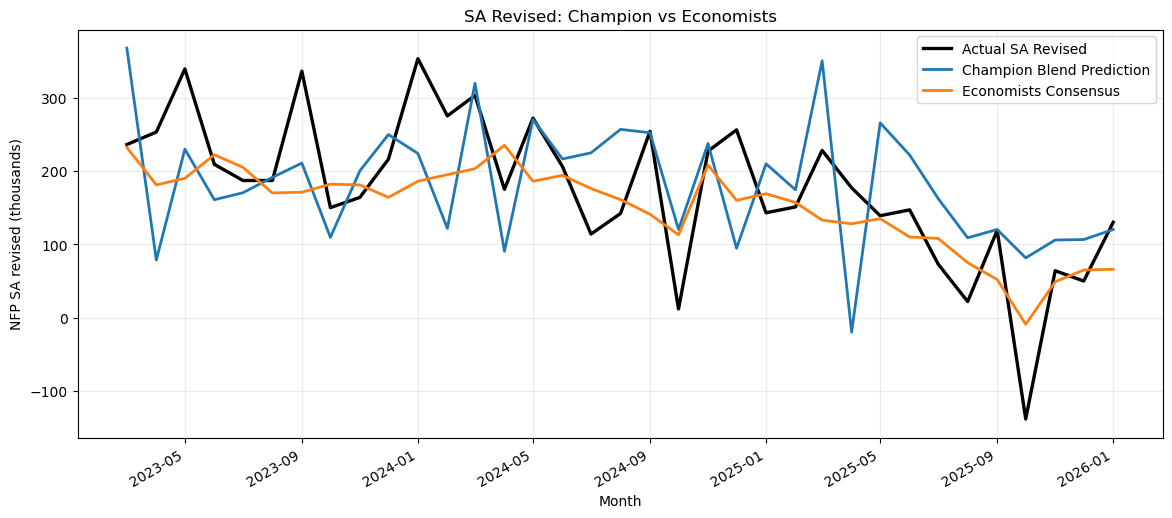

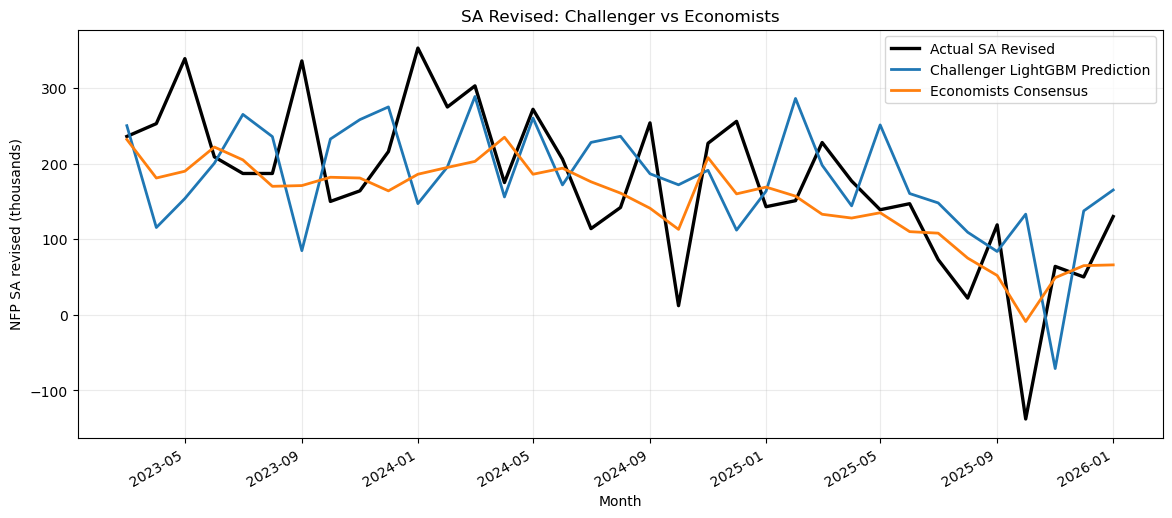

In [23]:
def plot_three_line(df: pd.DataFrame, model_col: str, model_label: str, title_suffix: str):
    z = df[["ds", "actual", model_col, "consensus_pred"]].dropna().sort_values("ds")
    if z.empty:
        raise ValueError(f"No overlapping rows for {model_label}")

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(z["ds"], z["actual"], color="black", linewidth=2.4, label="Actual SA Revised")
    ax.plot(z["ds"], z[model_col], color="#1f77b4", linewidth=2.0, label=f"{model_label} Prediction")
    ax.plot(z["ds"], z["consensus_pred"], color="#ff7f0e", linewidth=2.0, label="Economists Consensus")

    ax.set_title(f"SA Revised: {title_suffix}")
    ax.set_xlabel("Month")
    ax.set_ylabel("NFP SA revised (thousands)")
    ax.legend(loc="best")
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    plt.show()


plot_three_line(comparison_df, "champion_pred", "Champion Blend", "Champion vs Economists")
plot_three_line(comparison_df, "challenger_pred", "Challenger LightGBM", "Challenger vs Economists")


In [24]:
OUT_DIR = REPO_ROOT / "_output" / "consensus_comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

champ_table.to_csv(OUT_DIR / "champion_vs_consensus_metrics.csv")
chall_table.to_csv(OUT_DIR / "challenger_vs_consensus_metrics.csv")
comparison_df.to_csv(OUT_DIR / "consensus_model_merged.csv", index=False)

# Save chart PNGs as well.
for model_col, label, fname in [
    ("champion_pred", "Champion Blend", "champion_vs_consensus.png"),
    ("challenger_pred", "Challenger LightGBM", "challenger_vs_consensus.png"),
]:
    z = comparison_df[["ds", "actual", model_col, "consensus_pred"]].dropna().sort_values("ds")
    if z.empty:
        continue
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(z["ds"], z["actual"], color="black", linewidth=2.4, label="Actual SA Revised")
    ax.plot(z["ds"], z[model_col], color="#1f77b4", linewidth=2.0, label=f"{label} Prediction")
    ax.plot(z["ds"], z["consensus_pred"], color="#ff7f0e", linewidth=2.0, label="Economists Consensus")
    ax.set_title(f"SA Revised: {label} vs Economists")
    ax.set_xlabel("Month")
    ax.set_ylabel("NFP SA revised (thousands)")
    ax.legend(loc="best")
    ax.grid(alpha=0.25)
    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(OUT_DIR / fname, dpi=150, bbox_inches="tight")
    plt.close(fig)

print("Saved outputs to", OUT_DIR)
print("-", OUT_DIR / "champion_vs_consensus_metrics.csv")
print("-", OUT_DIR / "challenger_vs_consensus_metrics.csv")
print("-", OUT_DIR / "consensus_model_merged.csv")
print("-", OUT_DIR / "champion_vs_consensus.png")
print("-", OUT_DIR / "challenger_vs_consensus.png")


Saved outputs to /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor/_output/consensus_comparison
- /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor/_output/consensus_comparison/champion_vs_consensus_metrics.csv
- /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor/_output/consensus_comparison/challenger_vs_consensus_metrics.csv
- /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor/_output/consensus_comparison/consensus_model_merged.csv
- /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor/_output/consensus_comparison/champion_vs_consensus.png
- /Users/dhruvkohli/Desktop/Github Repos/NFP_Predictor/_output/consensus_comparison/challenger_vs_consensus.png
